# ==================================================
# Student Productivity Analytics Project
# Machine Learning Notebook
# ==================================================

# Goal:
# Build predictive models for:
# - Exam performance
# - Burnout risk

In [1]:
!pip install scikit-learn

In [2]:
# ==================================================
# Import Libraries
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

import os

In [3]:
# ==================================================
# Connect Google Drive
# ==================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==================================================
# Project Paths
# ==================================================

PROJECT_PATH = "/content/drive/MyDrive/student-productivity-analytics"

PROCESSED_DATA_PATH = f"{PROJECT_PATH}/data/processed"

MODELS_PATH = f"{PROJECT_PATH}/models"

VISUALS_PATH = f"{PROJECT_PATH}/visuals"

os.makedirs(MODELS_PATH, exist_ok=True)

os.makedirs(VISUALS_PATH, exist_ok=True)

In [5]:
# ==================================================
# Load Segmented Dataset
# ==================================================

dataset_path = (
    f"{PROCESSED_DATA_PATH}/"
    "student_productivity_segmented.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset Loaded!")

Dataset Loaded!


In [6]:
# ==================================================
# Dataset Preview
# ==================================================

df.head()

,Student_ID,Date,Persona,Age,Gender,Department,Year_of_Study,Sleep_Hours,Study_Hours,Screen_Time_Hours,...,Wellness_Score,Productivity_Efficiency,Digital_Distraction_Score,Wellness_Index,Study_Consistency_Score,Sleep_Deficit,Burnout_Risk_Score,Performance_Category,High_Risk_Flag,Student_Segment
0,1,2025-01-01,High Performer,18,Female,Information Technology,2,7.9,5.4,4.6,...,3.85,8.06,2.02,3.85,8.91,0.1,3.37,Good,0,3
1,1,2025-01-02,High Performer,18,Female,Information Technology,2,7.9,5.0,3.5,...,3.79,7.25,2.16,3.79,8.91,0.1,2.78,Average,0,3
2,1,2025-01-03,High Performer,18,Female,Information Technology,2,6.8,4.1,5.5,...,3.56,9.82,2.83,3.56,8.91,1.2,3.32,Average,0,3
3,1,2025-01-04,High Performer,18,Female,Information Technology,2,7.8,4.9,3.7,...,4.50,10.73,0.79,4.50,8.91,0.2,2.36,Good,0,3
4,1,2025-01-05,High Performer,18,Female,Information Technology,2,7.7,3.5,2.7,...,4.28,11.89,1.09,4.28,8.91,0.3,2.49,Average,0,3


In [7]:
# ==================================================
# Select Features
# ==================================================

features = [
    "Study_Hours",
    "Sleep_Hours",
    "Screen_Time_Hours",
    "Stress_Level",
    "Productivity_Score",
    "Focus_Score",
    "Attendance_Percentage"
]

X = df[features]

y = df["Exam_Score"]

print("Features and Label Ready!")

Features and Label Ready!


In [8]:
# ==================================================
# Train-Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Complete!")

Train-Test Split Complete!


In [9]:
# ==================================================
# Linear Regression Model
# ==================================================

regression_model = LinearRegression()

regression_model.fit(
    X_train,
    y_train
)

print("Regression Model Trained!")

Regression Model Trained!


In [10]:
# ==================================================
# Predict Exam Scores
# ==================================================

y_pred = regression_model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


In [11]:
# ==================================================
# Regression Evaluation
# ==================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))

print("Mean Squared Error:", round(mse, 2))

print("R2 Score:", round(r2, 2))

Mean Absolute Error: 4.18
Mean Squared Error: 27.86
R2 Score: 0.91


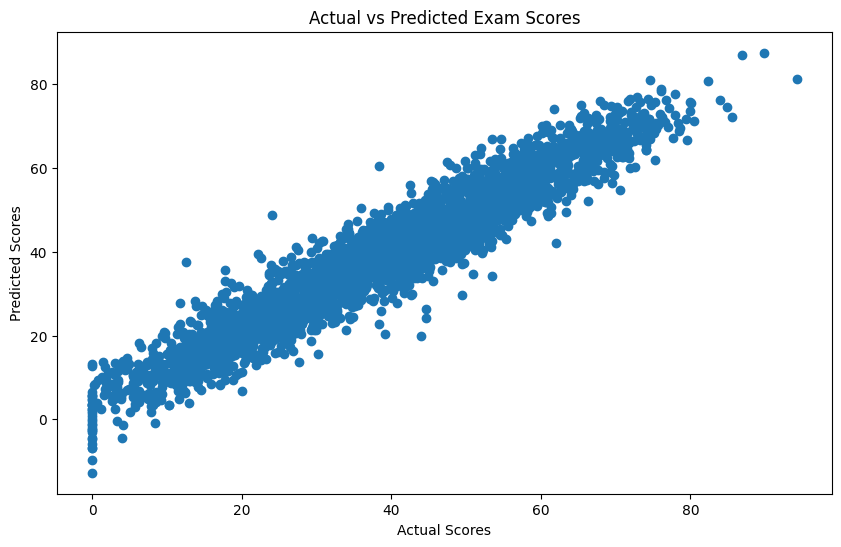

In [12]:
# ==================================================
# Actual vs Predicted Scores
# ==================================================

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Scores")

plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Exam Scores")

plt.show()

In [13]:
# ==================================================
# Classification Features
# ==================================================

classification_features = [
    "Study_Hours",
    "Sleep_Hours",
    "Screen_Time_Hours",
    "Stress_Level",
    "Mood_Score",
    "Productivity_Score",
    "Digital_Distraction_Score"
]

X = df[classification_features]

y = df["High_Risk_Flag"]

print("Classification Data Ready!")

Classification Data Ready!


In [14]:
# ==================================================
# Classification Train-Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# ==================================================
# Random Forest Classifier
# ==================================================

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

print("Classifier Trained!")

Classifier Trained!


In [16]:
# ==================================================
# Burnout Predictions
# ==================================================

y_pred = classifier.predict(X_test)

print("Classification Predictions Generated!")

Classification Predictions Generated!


In [17]:
# ==================================================
# Classification Evaluation
# ==================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 2))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.98

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2857
           1       0.88      0.69      0.77       143

    accuracy                           0.98      3000
   macro avg       0.93      0.84      0.88      3000
weighted avg       0.98      0.98      0.98      3000



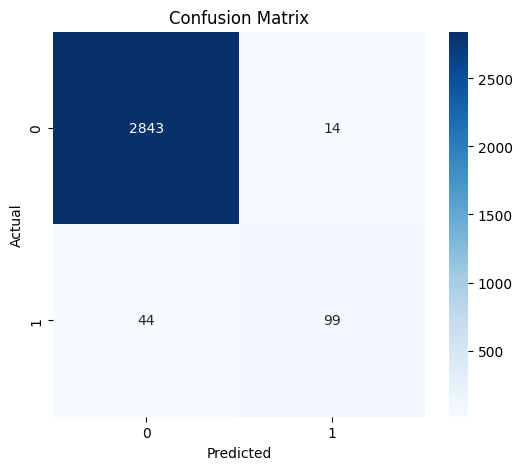

In [18]:
# ==================================================
# Confusion Matrix
# ==================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [19]:
# ==================================================
# Feature Importance
# ==================================================

importance = pd.DataFrame({
    "Feature": classification_features,
    "Importance": classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Stress_Level,0.301549
1,Sleep_Hours,0.262671
2,Screen_Time_Hours,0.120196
6,Digital_Distraction_Score,0.090610
4,Mood_Score,0.077282
5,Productivity_Score,0.076260
0,Study_Hours,0.071432


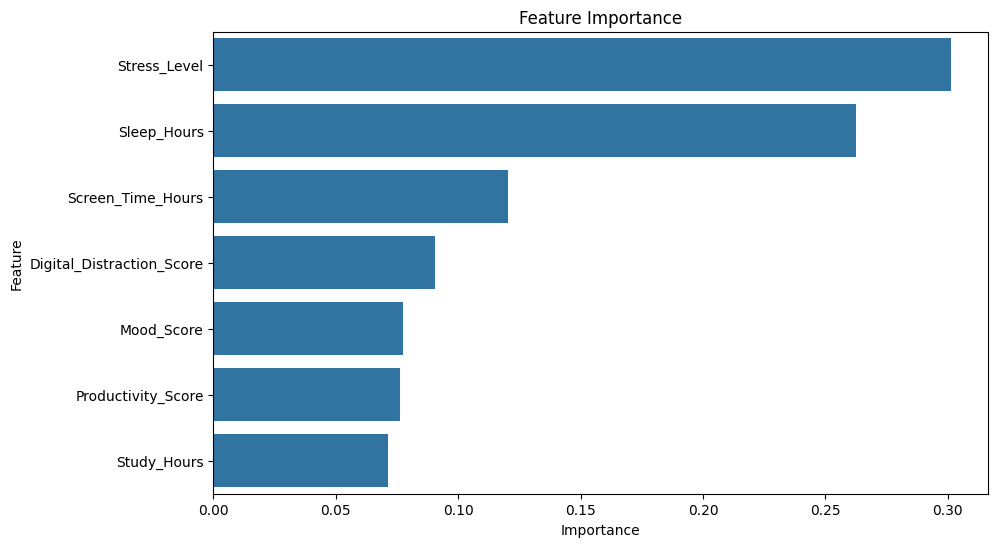

In [20]:
# ==================================================
# Feature Importance Visualization
# ==================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [21]:
# ==================================================
# Overfitting Concept
# ==================================================

print("""
Overfitting occurs when a model memorizes
training data instead of learning patterns.

Result:
- Excellent training performance
- Poor real-world performance
""")


Overfitting occurs when a model memorizes
training data instead of learning patterns.

Result:
- Excellent training performance
- Poor real-world performance



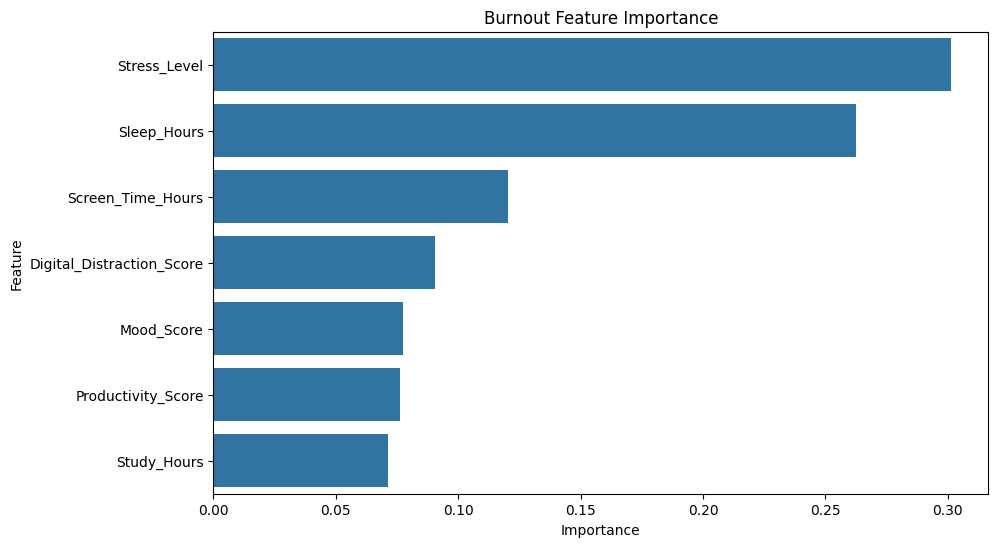

In [22]:
# ==================================================
# Save Feature Importance Visual
# ==================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Burnout Feature Importance")

feature_path = (
    f"{VISUALS_PATH}/feature_importance.png"
)

plt.savefig(feature_path)

plt.show()

In [23]:
# ==================================================
# Save ML Ready Dataset
# ==================================================

ml_dataset_path = (
    f"{PROCESSED_DATA_PATH}/"
    "student_productivity_ml_ready.csv"
)

df.to_csv(
    ml_dataset_path,
    index=False
)

print("ML Dataset Saved!")

ML Dataset Saved!


In [24]:
# ==================================================
# Machine Learning Insights
# ==================================================

print("Key ML Insights:")

print("- Student performance is predictable from behavioral data.")

print("- Burnout risk can be identified early.")

print("- Sleep and stress strongly influence outcomes.")

print("- Behavioral analytics improves intervention capability.")

print("- Productivity metrics help explain performance variation.")

Key ML Insights:
- Student performance is predictable from behavioral data.
- Burnout risk can be identified early.
- Sleep and stress strongly influence outcomes.
- Behavioral analytics improves intervention capability.
- Productivity metrics help explain performance variation.
